# Import modules and libraries

In [1]:
# See https://simba-bio.readthedocs.io/en/latest/multiome_shareseq_GRN.html

In [2]:
import os
import numpy as np
import pandas as pd
import simba as si
import pickle

si.__version__

/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/manuel.tardaguila/.local/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `

'1.2'

In [3]:
workdir = '/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA'
si.settings.set_workdir(workdir)

Saving results in: /group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA


In [4]:
si.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [5]:
# to make plots prettier
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

/localscratch/21406878.manuel.tardaguila/ipykernel_2615488/3381039072.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


In [6]:
import scanpy as sc

In [7]:
import re

# Load the processed files

In [8]:
workdir = '/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/'
si.settings.set_workdir(workdir)

Saving results in: /group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/


In [9]:
adata_C = si.read_h5ad(os.path.join(workdir,'adata_C.h5ad'))
adata_G = si.read_h5ad(os.path.join(workdir,'adata_G.h5ad'))
adata_M = si.read_h5ad(os.path.join(workdir,'adata_M.h5ad'))
adata_K = si.read_h5ad(os.path.join(workdir,'adata_K.h5ad'))
adata_P = si.read_h5ad(os.path.join(workdir,'adata_P.h5ad'))
adata_CP = si.read_h5ad(os.path.join(workdir,'adata_CP.h5ad'))

adata_PM = si.read_h5ad(os.path.join(workdir,'adata_PM.h5ad'))



adata_all = si.read_h5ad(os.path.join(workdir,'adata_all.h5ad'))

adata_cmp_CG = si.read_h5ad(os.path.join(workdir,'adata_cmp_CG.h5ad'))
adata_cmp_CM = si.read_h5ad(os.path.join(workdir,'adata_cmp_CM.h5ad'))

KeyboardInterrupt: 

# GRN

In [10]:
adata_M.obs_names

Index(['M_GATA3-2', 'M_FOXK1-1', 'M_THRB-1', 'M_Tcf12', 'M_NKX6-3', 'M_PAX1',
       'M_SPDEF-1', 'M_E2F', 'M_FOS_JUN', 'M_NEUROG2-1',
       ...
       'M_KLF17', 'M_Rfx5', 'M_ETV1-1', 'M_NR2F1', 'M_ISRE', 'M_SPIB',
       'M_NEUROG2', 'M_JunD', 'M_Nkx2.2', 'M_ATF7'],
      dtype='object', length=1069)

In [11]:
# Create a new column in adata_M.obs to store the original observation names
adata_M.obs['original_motif_name'] = adata_M.obs_names.copy()

In [12]:
print(adata_M.shape)

(1069, 50)


## Now put together motifs and genes

In [13]:
motifs_genes = pd.DataFrame(columns=['motif', 'gene'])
for x in adata_M.obs_names:
    x_split = x.split('_')
    for y in adata_G.obs_names:
        if y in x_split:
            motifs_genes.loc[motifs_genes.shape[0]] = [x,y]

In [14]:
print(motifs_genes.shape)

(589, 2)


In [15]:
motifs_genes.tail()

,motif,gene
584,M_KLF17,KLF17
585,M_NR2F1,NR2F1
586,M_SPIB,SPIB
587,M_NEUROG2,NEUROG2
588,M_ATF7,ATF7


## Remove duplicate rows

In [16]:
motifs_genes_unique = motifs_genes.drop_duplicates()

print(motifs_genes_unique.head())
print(f"Original number of rows: {motifs_genes.shape[0]}")
print(f"Number of unique rows: {motifs_genes_unique.shape[0]}")

       motif    gene
0   M_NKX6-3  NKX6-3
1  M_FOS_JUN     FOS
2  M_FOS_JUN     JUN
3      M_EN2     EN2
4    M_MEIS3   MEIS3
Original number of rows: 589
Number of unique rows: 589


## Remove composite motifs

In [17]:
pattern = r'^M_[^_]+_[^_]+.+$'

In [18]:
#motifs_genes_unique["motif"]

In [19]:
# Apply regex match to each value in the Series
motifs_genes_unique['is_composite_motif'] = motifs_genes_unique['motif'].str.match(pattern)

## Check if there are duplicates

In [20]:
genes = motifs_genes_unique["gene"]

In [21]:
motifs_genes_unique[genes.isin(genes[genes.duplicated()])].sort_values("gene")

,motif,gene,is_composite_motif
172,M_BATF_JUN,BATF,True
332,M_BATF,BATF,False
1,M_FOS_JUN,FOS,True
111,M_FOS_JUND,FOS,True
444,M_FOS_JUN-1,FOS,True
...,...,...,...
377,M_GATA1_TAL1,TAL1,True
236,M_TCF3,TCF3,False
14,M_TAL1_TCF3,TCF3,True
480,M_RXRA_VDR,VDR,True


In [22]:
filtered = motifs_genes_unique[motifs_genes_unique['is_composite_motif'] == False]

In [23]:
filtered.head

<bound method NDFrame.head of          motif     gene  is_composite_motif
0     M_NKX6-3   NKX6-3               False
3        M_EN2      EN2               False
4      M_MEIS3    MEIS3               False
5       M_KLF2     KLF2               False
6      M_TFAP4    TFAP4               False
..         ...      ...                 ...
584    M_KLF17    KLF17               False
585    M_NR2F1    NR2F1               False
586     M_SPIB     SPIB               False
587  M_NEUROG2  NEUROG2               False
588     M_ATF7     ATF7               False

[524 rows x 3 columns]>

In [24]:
print(filtered.shape)

(524, 3)


In [25]:
motifs = filtered["motif"]

In [26]:
print(motifs.shape)

(524,)


## Check if RUNX1 and CUX1 motifs are present

In [27]:
print("\n--- Rows containing 'CUX1' motif ---")
print(filtered[filtered['motif'].str.contains('CUX1', na=False)])


--- Rows containing 'CUX1' motif ---
      motif  gene  is_composite_motif
132  M_CUX1  CUX1               False


In [32]:
print("\n--- Rows containing 'CUX1' motif ---")
print(filtered[filtered['motif'].str.contains('RUNX1', na=False)])


--- Rows containing 'CUX1' motif ---
       motif   gene  is_composite_motif
555  M_RUNX1  RUNX1               False


## Create the lists

In [33]:
list_tf_motif = filtered['motif'].tolist()
list_tf_gene = filtered['gene'].tolist()

df_metrics_motif = adata_cmp_CM.var.copy()
df_metrics_gene = adata_cmp_CG.var.copy()

In [34]:
df_metrics_motif.head()

,max,std,gini,entropy
M_GATA3-2,4.455484,3.855971,0.968569,5.929346
M_FOXK1-1,4.399029,4.672313,0.989876,4.023088
M_THRB-1,4.174938,3.380144,0.955102,6.408102
M_Tcf12,3.422156,6.240797,0.996765,2.111938
M_NKX6-3,4.260653,4.600081,0.984200,4.260064


In [35]:
df_metrics_gene.head()

,max,std,gini,entropy
ZNF140,1.207881,0.414686,0.231379,9.240115
MFSD9,1.577956,0.383481,0.219276,9.239024
AC112496.1,1.507132,0.618570,0.331556,9.147475
AC100778.3,1.500990,0.472221,0.276782,9.194577
NKX2-6,1.667477,0.558074,0.348098,9.095263


## Plot SIMBA metrics in order to help set the cutoffs later

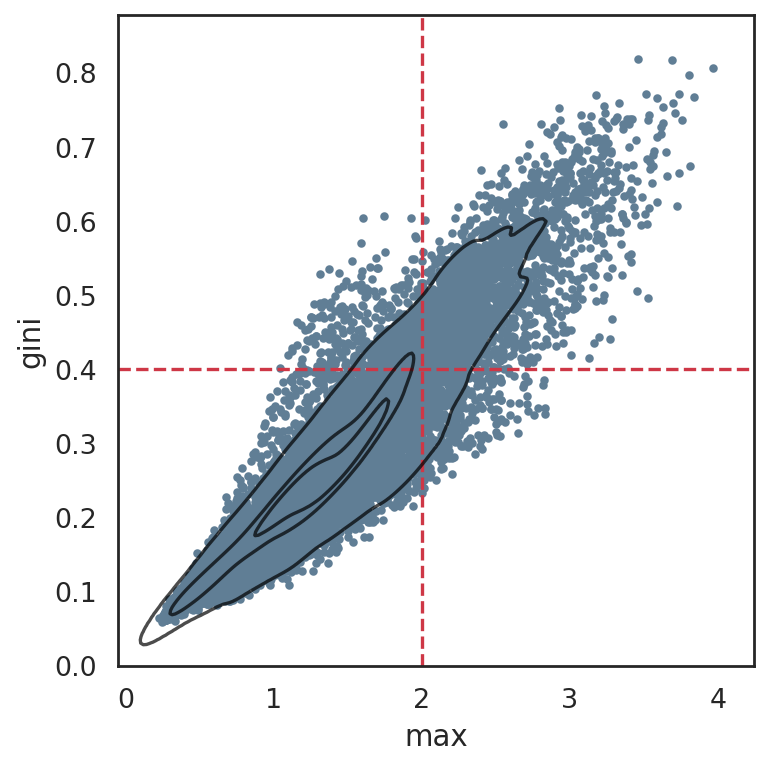

In [36]:
si.pl.entity_metrics(adata_cmp_CG,x='max',y='gini',
                     show_texts=False,
                     show_cutoff=True,
                     show_contour=True,
                     c='#607e95',
                     cutoff_x=2,
                     cutoff_y=0.4)

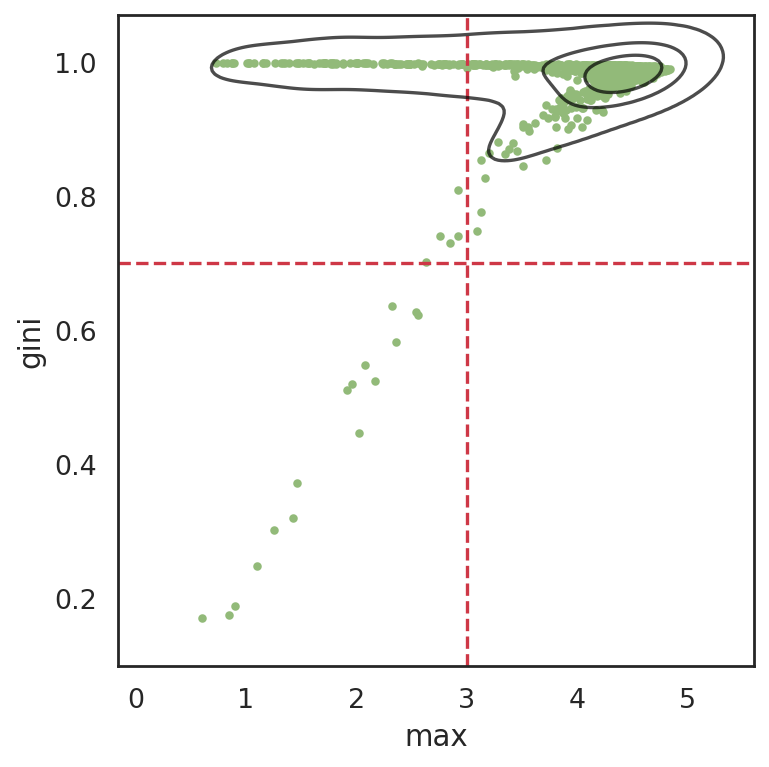

In [37]:
si.pl.entity_metrics(adata_cmp_CM,x='max',y='gini',
                     show_texts=False,
                     show_cutoff=True,
                     show_contour=True,
                     c='#92ba79',
                     cutoff_x=3,
                     cutoff_y=0.7)

## Identify master regulators

In [38]:
# --- Diagnostic prints ---
print("\n--- Debugging `adata_all.obs` columns ---")
print("Columns in adata_all.obs:", adata_all.obs.columns.tolist())
print("'entity_anno' column exists:", 'entity_anno' in adata_all.obs.columns)

if 'entity_anno' in adata_all.obs.columns:
    print("\nValue counts for 'entity_anno' (first 10 if too many unique values):")
    print(adata_all.obs['entity_anno'].value_counts().head(10))
    print("\nHead of adata_all.obs['entity_anno']:")
    print(adata_all.obs['entity_anno'].head())
    print("\nTail of adata_all.obs['entity_anno']:")
    print(adata_all.obs['entity_anno'].tail())
else:
    print("\nPROBLEM: 'entity_anno' column is missing from adata_all.obs!")
print("-" * 30)



--- Debugging `adata_all.obs` columns ---
Columns in adata_all.obs: ['seurat_clusters', 'time_point', 'celltype', 'clone_line', 'Genotype', 'id_dataset']
'entity_anno' column exists: False

PROBLEM: 'entity_anno' column is missing from adata_all.obs!
------------------------------


### add entity anno to adata_all

In [44]:
## add annotations of all entities
adata_all.obs['entity_anno'] = ""
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'seurat_clusters'].tolist()
adata_all.obs.loc[adata_G.obs_names, 'entity_anno'] = 'gene'
adata_all.obs.loc[adata_P.obs_names, 'entity_anno'] = 'peak'
adata_all.obs.loc[adata_K.obs_names, 'entity_anno'] = 'kmer'
adata_all.obs.loc[adata_M.obs_names, 'entity_anno'] = 'motif'

In [45]:
adata_all.obs.head()


,seurat_clusters,time_point,celltype,clone_line,Genotype,id_dataset,entity_anno
MCO_1280_TTTCACCCATTAGCGC-1,3,72_hours,2.0,Del_80bp_2,Del_80bp,ref,3
MCO_1279_CTCGACAAGGACAACA-1,3,48_hours,2.0,rs139141690_2,rs139141690,ref,3
MCO_1279_CAGAACCGTTTATCGC-1,5,48_hours,1.0,wt_3,wt,ref,5
MCO_1280_GGGCTAACATTAAGTC-1,2,72_hours,0.0,Del_16bp_1,Del_16bp,ref,2
MCO_1281_CGCATATAGGATAAAC-1,2,96_hours,0.0,Del_16bp_1,Del_16bp,ref,2


In [46]:
df_MR = si.tl.find_master_regulators(adata_all,
                                     list_tf_motif=list_tf_motif,
                                     list_tf_gene=list_tf_gene,
                                     cutoff_gene_max=2,
                                     cutoff_gene_gini=0.4,
                                     cutoff_motif_max=3,
                                     cutoff_motif_gini=0.7,
                                     metrics_gene=df_metrics_gene,
                                     metrics_motif=df_metrics_motif
                                    )

Adding motif metrics ...
Adding gene metrics ...
Computing distances between TF motifs and genes ...


/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/simba/tools/_post_training.py:619: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.906625684598537' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_MR.loc[i, 'dist'] = dist_MG.loc[x_motif, x_gene]


filtering master regulators based on gene metrics:
Gini index
max
filtering master regulators based on motif metrics:
Gini index
max


In [48]:
print("--- Head of df_MR ---")
print(df_MR.head())

print("\n--- Shape of df_MR ---")
print(df_MR.shape)

--- Head of df_MR ---
      motif    gene  rank      dist  max_motif  std_motif  gini_motif  \
0  M_HOXD10  HOXD10    51  2.708817   4.075714   4.413661    0.989808   
1    M_NOTO    NOTO   213  4.228749   4.330792   3.743510    0.981502   
2  M_ZSCAN4  ZSCAN4   231  2.195714   4.296320   4.101359    0.969299   
3   M_NR2F1   NR2F1  2512  2.827744   3.176817   5.205902    0.996538   
4   M_BARX1   BARX1  4520  2.357680   4.378717   3.851570    0.975107   

   entropy_motif  max_gene  std_gene  gini_gene  entropy_gene  
0       3.552276  2.009114  0.715661   0.455863      8.918017  
1       4.360862  2.001572  0.711538   0.449749      8.935908  
2       5.846579  2.105337  0.752148   0.474461      8.891231  
3       1.630908  2.165879  0.705053   0.435405      8.969948  
4       5.075177  2.441416  0.705409   0.429565      8.964658  

--- Shape of df_MR ---
(39, 12)


## Identify target genes

## make sure the indices of motifs are the same as in `motifs_genes_unique`

In [49]:
adata_PM.var.index = 'M_' + adata_PM.var.index

## get the overlap between peaks and gene loci

In [50]:
reference_genome = '/processing_data/reference_datasets/iGenomes/2022.1/Homo_sapiens/NCBI/GRCh38/Sequence/WholeGenomeFasta/genome.fa'

In [51]:
adata_CP

AnnData object with n_obs × n_vars = 11250 × 356772
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblF

In [52]:
adata_CP.var_names

Index(['chr1-10063-10371', 'chr1-17238-17447', 'chr1-115501-115774',
       'chr1-138879-139097', 'chr1-180694-181047', 'chr1-181290-181588',
       'chr1-184068-184460', 'chr1-191239-191551', 'chr1-605114-605610',
       'chr1-629563-630703',
       ...
       'chrY-56857390-56858213', 'chrY-56858577-56859056',
       'chrY-56860234-56860510', 'chrY-56861341-56861666',
       'chrY-56869643-56870178', 'chrY-56870723-56871184',
       'chrY-56873548-56874117', 'chrY-56875917-56876293',
       'chrY-56877514-56877843', 'chrY-56879608-56880130'],
      dtype='object', length=356772)

### Print the first few to see the format

In [53]:
adata_CP.var_names[:5].to_list()

['chr1-10063-10371',
 'chr1-17238-17447',
 'chr1-115501-115774',
 'chr1-138879-139097',
 'chr1-180694-181047']

### Extrat chr start and end as separate columns in ann data

In [54]:
# Split var_names into chrosome, start, and end positions
adata_CP.var[['chr', 'start', 'end']] = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')


In [55]:
adata_CP.var[['chrom']]

,chrom
chr1-10063-10371,NaN
chr1-17238-17447,NaN
chr1-115501-115774,NaN
chr1-138879-139097,NaN
chr1-180694-181047,NaN
...,...
chrY-56870723-56871184,NaN
chrY-56873548-56874117,NaN
chrY-56875917-56876293,NaN
chrY-56877514-56877843,NaN


In [56]:
matched = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')

matched


,0,1,2
0,chr1,10063,10371
1,chr1,17238,17447
2,chr1,115501,115774
3,chr1,138879,139097
4,chr1,180694,181047
...,...,...,...
356767,chrY,56870723,56871184
356768,chrY,56873548,56874117
356769,chrY,56875917,56876293
356770,chrY,56877514,56877843


In [57]:
# Check rows where it failed
bad_rows = adata_CP.var_names[matched.isnull().any(axis=1)]
bad_rows[:10].to_list()  # Print first few problem entries

[]

In [58]:
matched.keys

<bound method NDFrame.keys of            0         1         2
0       chr1     10063     10371
1       chr1     17238     17447
2       chr1    115501    115774
3       chr1    138879    139097
4       chr1    180694    181047
...      ...       ...       ...
356767  chrY  56870723  56871184
356768  chrY  56873548  56874117
356769  chrY  56875917  56876293
356770  chrY  56877514  56877843
356771  chrY  56879608  56880130

[356772 rows x 3 columns]>

In [59]:
# Extract chromosome, start, end from var_names
adata_CP.var[['chrom', 'start', 'end']] = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')


In [60]:
adata_CP.var[['chrom', 'start', 'end']].head()


,chrom,start,end
chr1-10063-10371,NaN,NaN,NaN
chr1-17238-17447,NaN,NaN,NaN
chr1-115501-115774,NaN,NaN,NaN
chr1-138879-139097,NaN,NaN,NaN
chr1-180694-181047,NaN,NaN,NaN


In [61]:
print(type(adata_CP.var_names))

<class 'pandas.core.indexes.base.Index'>


#### Convert index

In [62]:
var_names_str = adata_CP.var_names.astype(str)

var_names_str

Index(['chr1-10063-10371', 'chr1-17238-17447', 'chr1-115501-115774',
       'chr1-138879-139097', 'chr1-180694-181047', 'chr1-181290-181588',
       'chr1-184068-184460', 'chr1-191239-191551', 'chr1-605114-605610',
       'chr1-629563-630703',
       ...
       'chrY-56857390-56858213', 'chrY-56858577-56859056',
       'chrY-56860234-56860510', 'chrY-56861341-56861666',
       'chrY-56869643-56870178', 'chrY-56870723-56871184',
       'chrY-56873548-56874117', 'chrY-56875917-56876293',
       'chrY-56877514-56877843', 'chrY-56879608-56880130'],
      dtype='object', length=356772)

#### Create a separate table with the extraction of the fields

In [63]:
test = var_names_str.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')

test.columns = ['chr', 'start', 'end']
test.index = adata_CP.var_names

print(test[:5]) 

                     chr   start     end
chr1-10063-10371    chr1   10063   10371
chr1-17238-17447    chr1   17238   17447
chr1-115501-115774  chr1  115501  115774
chr1-138879-139097  chr1  138879  139097
chr1-180694-181047  chr1  180694  181047


#### Assign the table to the columns

In [64]:
adata_CP.var[['chr', 'start', 'end']] = test

In [65]:
adata_CP.var[['chr', 'start', 'end']]

,chr,start,end
chr1-10063-10371,chr1,10063,10371
chr1-17238-17447,chr1,17238,17447
chr1-115501-115774,chr1,115501,115774
chr1-138879-139097,chr1,138879,139097
chr1-180694-181047,chr1,180694,181047
...,...,...,...
chrY-56870723-56871184,chrY,56870723,56871184
chrY-56873548-56874117,chrY,56873548,56874117
chrY-56875917-56876293,chrY,56875917,56876293
chrY-56877514-56877843,chrY,56877514,56877843


#### change start and end to integers

In [66]:
adata_CP.var[['start', 'end']] = adata_CP.var[['start', 'end']].astype(int)

## Gene scores tool

In [67]:
_ = si.tl.gene_scores(adata_CP,genome='hg38',use_gene_weigt=True,use_top_pcs=False)

Gene scores are being calculated for the first time
`use_precomputed` has been ignored
Processing: 0.0%
Processing: 20.0%
Processing: 40.0%
Processing: 60.0%
Processing: 80.0%


## Create the dict of tf targets

In [68]:
dict_tf_targets = si.tl.find_target_genes(adata_all,
                                          adata_PM,
                                          list_tf_motif=list_tf_motif,
                                          list_tf_gene=list_tf_gene,
                                          adata_CP=adata_CP,
                                          cutoff_gene=5000)

Preprocessing ...
#genes: 30028
#peaks: 713544
#genes-associated peaks: 337606
computing distances between genes and genes-associated peaks ...
Saving variables into `.uns['tf_targets']` ...
searching for target genes of M_NKX6-3
#candinate genes is 400
removing duplicate genes ...
removing genes that do not contain TF motif ...
#candinate genes is 105
completed: 0.0%
completed: 20.0%
completed: 40.0%
completed: 60.0%
completed: 80.0%
Pruning candidate genes based on nearby peaks ...
Pruning candidate genes based on average rank ...
searching for target genes of M_EN2
#candinate genes is 400
removing duplicate genes ...
removing genes that do not contain TF motif ...
#candinate genes is 73
completed: 0.0%
completed: 19.2%
completed: 38.4%
completed: 57.5%
completed: 76.7%
completed: 95.9%
Pruning candidate genes based on nearby peaks ...
Pruning candidate genes based on average rank ...
searching for target genes of M_MEIS3
#candinate genes is 400
removing duplicate genes ...
removing 

## Check the keys

In [70]:
dict_tf_targets.keys()

dict_keys(['M_NKX6-3', 'M_EN2', 'M_MEIS3', 'M_KLF2', 'M_TFAP4', 'M_PBX2', 'M_HOXC9', 'M_ZEB1', 'M_STAT6', 'M_IRF2', 'M_ZNF274', 'M_MEOX2', 'M_ZBTB33', 'M_SMAD3', 'M_GLIS2', 'M_ZBTB7A', 'M_FOSL2', 'M_GCM1', 'M_HOXC4', 'M_RARG', 'M_MSX1', 'M_FOXP1', 'M_SOX13', 'M_RFX5', 'M_VENTX', 'M_ETV1', 'M_ELF5', 'M_MAF', 'M_ZNF354C', 'M_NFE2', 'M_RAX2', 'M_STAT4', 'M_PROX1', 'M_POU5F1', 'M_TFEB', 'M_HSF1', 'M_GATA3', 'M_ZEB2', 'M_FOXA2', 'M_SOX4', 'M_HES1', 'M_MAFF', 'M_JDP2', 'M_GRHL2', 'M_CRX', 'M_SPI1', 'M_FOXN3', 'M_ZBTB32', 'M_SOX2', 'M_ZNF449', 'M_MSANTD3', 'M_NFKB2', 'M_XBP1', 'M_ZNF528', 'M_SCRT2', 'M_LHX6', 'M_FOXP2', 'M_PRDM14', 'M_FOXP3', 'M_FOXC2', 'M_TP73', 'M_IRF6', 'M_SHOX', 'M_TFCP2', 'M_ARNT2', 'M_BACH2', 'M_PKNOX2', 'M_GRHL1', 'M_MEOX1', 'M_SNAI3', 'M_TGIF2', 'M_RFX1', 'M_HOXB4', 'M_NFKB1', 'M_RUNX2', 'M_TEAD1', 'M_MYNN', 'M_NR2F6', 'M_FOS', 'M_REL', 'M_FEV', 'M_CREM', 'M_RXRG', 'M_ZNF692', 'M_ARGFX', 'M_TBX15', 'M_IRF3', 'M_RARA', 'M_ZBTB14', 'M_HOXC10', 'M_BARHL2', 'M_ZBTB26', 'M

In [71]:
matches = [key for key in dict_tf_targets.keys() if "RUNX1" in key]

matches

['M_RUNX1']

In [72]:
matches = [key for key in dict_tf_targets.keys() if "CUX1" in key]

matches

['M_CUX1']

In [73]:
type(dict_tf_targets)

dict

In [74]:
value = dict_tf_targets.get("M_RUNX1")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene


In [75]:
value = dict_tf_targets.get("M_CUX1")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene


In [80]:
value = dict_tf_targets.get("M_GATA1")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene


In [82]:
print("\n--- Debugging adata_CP.var['chrom'] ---")

# Check if 'chrom' column exists
if 'chrom' in adata_CP.var.columns:
    chrom_series = adata_CP.var['chrom']
    print(f"Data type of 'chrom' column: {chrom_series.dtype}")
    print("\nValue counts for 'chrom' column:")
    print(chrom_series.value_counts(dropna=False).head()) # Check values and NaNs
    print("\nUnique values and their types in 'chrom' column (first 10, or all if less):")
    unique_types = set()
    for val in chrom_series.dropna().unique(): # Iterate unique non-NaN values
        unique_types.add(type(val))
    print(unique_types)

    # Find specific non-string elements if any
    non_string_elements = chrom_series[~chrom_series.apply(lambda x: isinstance(x, (str, bytes)) or pd.isna(x))]
    if not non_string_elements.empty:
        print("\nFound non-string, non-NaN elements in 'chrom' column:")
        print(non_string_elements.head())
    else:
        print("\nAll non-NaN elements in 'chrom' column appear to be strings or bytes.")
else:
    print("Error: 'chrom' column not found in adata_CP.var!")

print("-" * 30)


--- Debugging adata_CP.var['chrom'] ---
Data type of 'chrom' column: object

Value counts for 'chrom' column:
chrom
NaN    356772
Name: count, dtype: int64

Unique values and their types in 'chrom' column (first 10, or all if less):
set()

All non-NaN elements in 'chrom' column appear to be strings or bytes.
------------------------------


In [83]:
print("\n--- Debugging adata_CP.var['chr'] ---")

# Check if 'chr' column exists
if 'chr' in adata_CP.var.columns:
    chr_series = adata_CP.var['chr']
    print(f"Data type of 'chr' column: {chr_series.dtype}")
    print("\nValue counts for 'chr' column:")
    print(chr_series.value_counts(dropna=False).head()) # Check values and NaNs
    print("\nUnique values and their types in 'chr' column (first 10, or all if less):")
    unique_types = set()
    for val in chr_series.dropna().unique(): # Iterate unique non-NaN values
        unique_types.add(type(val))
    print(unique_types)

    # Find specific non-string elements if any
    non_string_elements = chr_series[~chr_series.apply(lambda x: isinstance(x, (str, bytes)) or pd.isna(x))]
    if not non_string_elements.empty:
        print("\nFound non-string, non-NaN elements in 'chr' column:")
        print(non_string_elements.head())
    else:
        print("\nAll non-NaN elements in 'chr' column appear to be strings or bytes.")
else:
    print("Error: 'chr' column not found in adata_CP.var!")

print("-" * 30)


--- Debugging adata_CP.var['chr'] ---
Data type of 'chr' column: category

Value counts for 'chr' column:
chr
chr1    35039
chr2    29956
chr6    24212
chr3    22472
chr7    21681
Name: count, dtype: int64

Unique values and their types in 'chr' column (first 10, or all if less):
{<class 'str'>}

All non-NaN elements in 'chr' column appear to be strings or bytes.
------------------------------


In [84]:
adata_CP.var['chrom'] = adata_CP.var['chr']


In [85]:
print("\n--- Debugging adata_CP.var['chrom'] ---")

# Check if 'chrom' column exists
if 'chrom' in adata_CP.var.columns:
    chrom_series = adata_CP.var['chrom']
    print(f"Data type of 'chrom' column: {chrom_series.dtype}")
    print("\nValue counts for 'chrom' column:")
    print(chrom_series.value_counts(dropna=False).head()) # Check values and NaNs
    print("\nUnique values and their types in 'chrom' column (first 10, or all if less):")
    unique_types = set()
    for val in chrom_series.dropna().unique(): # Iterate unique non-NaN values
        unique_types.add(type(val))
    print(unique_types)

    # Find specific non-string elements if any
    non_string_elements = chrom_series[~chrom_series.apply(lambda x: isinstance(x, (str, bytes)) or pd.isna(x))]
    if not non_string_elements.empty:
        print("\nFound non-string, non-NaN elements in 'chrom' column:")
        print(non_string_elements.head())
    else:
        print("\nAll non-NaN elements in 'chrom' column appear to be strings or bytes.")
else:
    print("Error: 'chrom' column not found in adata_CP.var!")

print("-" * 30)


--- Debugging adata_CP.var['chrom'] ---
Data type of 'chrom' column: category

Value counts for 'chrom' column:
chrom
chr1    35039
chr2    29956
chr6    24212
chr3    22472
chr7    21681
Name: count, dtype: int64

Unique values and their types in 'chrom' column (first 10, or all if less):
{<class 'str'>}

All non-NaN elements in 'chrom' column appear to be strings or bytes.
------------------------------


# SAVE RESULTS

In [86]:
adata_CP.write(os.path.join(workdir,'adata_CP.h5ad'))


In [77]:
with open('/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/dict_tf_targets.pickle', 'wb') as handle:
    pickle.dump(dict_tf_targets, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Read it back

In [78]:
with open('/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/dict_tf_targets.pickle', 'rb') as handle:
    dict_tf_targets = pickle.load(handle)

In [79]:
dict_tf_targets.keys()

dict_keys(['M_NKX6-3', 'M_EN2', 'M_MEIS3', 'M_KLF2', 'M_TFAP4', 'M_PBX2', 'M_HOXC9', 'M_ZEB1', 'M_STAT6', 'M_IRF2', 'M_ZNF274', 'M_MEOX2', 'M_ZBTB33', 'M_SMAD3', 'M_GLIS2', 'M_ZBTB7A', 'M_FOSL2', 'M_GCM1', 'M_HOXC4', 'M_RARG', 'M_MSX1', 'M_FOXP1', 'M_SOX13', 'M_RFX5', 'M_VENTX', 'M_ETV1', 'M_ELF5', 'M_MAF', 'M_ZNF354C', 'M_NFE2', 'M_RAX2', 'M_STAT4', 'M_PROX1', 'M_POU5F1', 'M_TFEB', 'M_HSF1', 'M_GATA3', 'M_ZEB2', 'M_FOXA2', 'M_SOX4', 'M_HES1', 'M_MAFF', 'M_JDP2', 'M_GRHL2', 'M_CRX', 'M_SPI1', 'M_FOXN3', 'M_ZBTB32', 'M_SOX2', 'M_ZNF449', 'M_MSANTD3', 'M_NFKB2', 'M_XBP1', 'M_ZNF528', 'M_SCRT2', 'M_LHX6', 'M_FOXP2', 'M_PRDM14', 'M_FOXP3', 'M_FOXC2', 'M_TP73', 'M_IRF6', 'M_SHOX', 'M_TFCP2', 'M_ARNT2', 'M_BACH2', 'M_PKNOX2', 'M_GRHL1', 'M_MEOX1', 'M_SNAI3', 'M_TGIF2', 'M_RFX1', 'M_HOXB4', 'M_NFKB1', 'M_RUNX2', 'M_TEAD1', 'M_MYNN', 'M_NR2F6', 'M_FOS', 'M_REL', 'M_FEV', 'M_CREM', 'M_RXRG', 'M_ZNF692', 'M_ARGFX', 'M_TBX15', 'M_IRF3', 'M_RARA', 'M_ZBTB14', 'M_HOXC10', 'M_BARHL2', 'M_ZBTB26', 'M

In [99]:
value = dict_tf_targets.get("M_GATA3")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene
ARMH2,3329.0,yes,6651,7,662,151608,3312,3312
ZNF319,3882.5,yes,7652,113,804,804,6677,6677
FA2H,3926.5,yes,7671,182,508,5354,5933,5933
ZNF622,4266.5,yes,8431,102,67,67,18819,18819
LILRA6,4297.0,yes,8508,86,4016,7600,527,527
PSPN,4511.5,yes,8988,35,43,43,4673,4673
SLC52A1,4588.5,yes,9068,109,73,73,7036,7036
CAMLG,4666.0,yes,9245,87,430,430,40308,40308
SDE2,4836.0,yes,9646,26,8196,11145,264,264
C17orf64,4876.5,yes,9627,126,15245,40870,369,369


In [94]:
#dict_tf_targets

## Explore what peaks are associated to which genes

In [100]:
adata_CP

AnnData object with n_obs × n_vars = 11250 × 356772
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblF

In [101]:
print("Columns in adata_CP.var after running gene_scores:")
print(adata_CP.var.columns.tolist())

Columns in adata_CP.var after running gene_scores:
['count', 'percentile', 'AA', 'AC', 'AG', 'AT', 'CA', 'CC', 'CG', 'CT', 'GA', 'GC', 'GG', 'GT', 'TA', 'TC', 'TG', 'TT', 'GC.percent', 'sequence.length', 'AA.1', 'AC.1', 'AG.1', 'AT.1', 'CA.1', 'CC.1', 'CG.1', 'CT.1', 'GA.1', 'GC.1', 'GG.1', 'GT.1', 'TA.1', 'TC.1', 'TG.1', 'TT.1', 'GC.percent.1', 'sequence.length.1', 'AA.2', 'AC.2', 'AG.2', 'AT.2', 'CA.2', 'CC.2', 'CG.2', 'CT.2', 'GA.2', 'GC.2', 'GG.2', 'GT.2', 'TA.2', 'TC.2', 'TG.2', 'TT.2', 'GC.percent.2', 'sequence.length.2', 'n_counts', 'n_cells', 'pct_cells', 'chrom', 'start', 'end', 'chr']


In [102]:
print("\nHead of adata_CP.var (showing gene scores and other annotations):")
print(adata_CP.var.head())


Head of adata_CP.var (showing gene scores and other annotations):
                    count  percentile    AA    AC    AG    AT    CA     CC  \
chr1-10063-10371    322.0    0.640437  52.0  51.0   0.0   0.0   7.0  110.0   
chr1-17238-17447     53.0    0.060778   5.0  13.0  15.0   9.0  25.0   18.0   
chr1-115501-115774  364.0    0.670756  27.0  18.0  21.0  18.0  24.0   12.0   
chr1-138879-139097  218.0    0.531648   3.0   9.0  30.0   7.0  14.0   15.0   
chr1-180694-181047  464.0    0.725351  52.0  54.0   4.0   0.0   6.0  109.0   

                     CG    CT  ...  TT.2  GC.percent.2  sequence.length.2  \
chr1-10063-10371    0.0  44.0  ...   0.0     52.103560                309   
chr1-17238-17447    2.0  22.0  ...   9.0     57.142857                210   
chr1-115501-115774  2.0  18.0  ...  26.0     39.416058                274   
chr1-138879-139097  4.0  11.0  ...  12.0     58.447489                219   
chr1-180694-181047  6.0  51.0  ...   0.0     53.672316                354   

 

In [104]:
print("\nKeys in adata_CP.uns:")
print(adata_CP.uns.keys())


Keys in adata_CP.uns:
dict_keys(['disc', 'gene_scores'])


In [105]:
gene_scores_data = adata_CP.uns['gene_scores']

print("\n--- Type of the 'gene_scores' object in adata_CP.uns ---")
print(type(gene_scores_data))

print("\n--- Head of the 'gene_scores' data ---")
# Assuming it's a pandas DataFrame, you can use .head()
# If it's a dictionary or other type, you might need to adjust (e.g., print(gene_scores_data) or iterate)
try:
    print(gene_scores_data.head())
except AttributeError:
    print("'.head()' method not found, printing full object:")
    print(gene_scores_data)

print("\n--- Shape of the 'gene_scores' data (if DataFrame) ---")
try:
    print(gene_scores_data.shape)
except AttributeError:
    print("'.shape' attribute not found for this object.")


--- Type of the 'gene_scores' object in adata_CP.uns ---
<class 'dict'>

--- Head of the 'gene_scores' data ---
'.head()' method not found, printing full object:
{'overlap':         chr_p   start_p     end_p    id_p chr_g   start_g     end_g  \
0        chr1     10063     10371       0  chr1         0    100000   
1        chr1     10063     10371       0  chr1         0    100000   
2        chr1     10063     10371       0  chr1         0    100000   
3        chr1     10063     10371       0  chr1         0    117436   
4        chr1     10063     10371       0  chr1         0    100000   
...       ...       ...       ...     ...   ...       ...       ...   
1077396  chrY  56870723  56871184  356767  chrY  56854254  56968979   
1077397  chrY  56873548  56874117  356768  chrY  56854254  56968979   
1077398  chrY  56875917  56876293  356769  chrY  56854254  56968979   
1077399  chrY  56877514  56877843  356770  chrY  56854254  56968979   
1077400  chrY  56879608  56880130  356771  c

In [106]:
overlap_df = adata_CP.uns['gene_scores']['overlap']
print("\nAccessed 'overlap' DataFrame head:")
print(overlap_df.head())


Accessed 'overlap' DataFrame head:
  chr_p  start_p  end_p  id_p chr_g  start_g   end_g     symbol_g  score_g  \
0  chr1    10063  10371     0  chr1        0  100000      DDX11L1        0   
1  chr1    10063  10371     0  chr1        0  100000    MIR1302-2        0   
2  chr1    10063  10371     0  chr1        0  100000  MIR1302-2HG        0   
3  chr1    10063  10371     0  chr1        0  117436    MIR6859-1        0   
4  chr1    10063  10371     0  chr1        0  100000        OR4F5        0   

  strand_g   id_g     dist  
0        +   4830      0.0  
1        +  25224  14994.0  
2        +  25225  14554.0  
3        -  26809   6997.0  
4        +  28944  53719.0  


In [107]:
gene_scores = overlap_df['score_g']
print("\nHead of 'score_g' column (your gene scores):")
print(gene_scores.head())
print(f"\nType of gene_scores: {type(gene_scores)}")
print(f"Shape of gene_scores: {gene_scores.shape}")


Head of 'score_g' column (your gene scores):
0    0
1    0
2    0
3    0
4    0
Name: score_g, dtype: int64

Type of gene_scores: <class 'pandas.core.series.Series'>
Shape of gene_scores: (1077401,)


In [108]:
# Subset the DataFrame to include only rows where 'score_g' is greater than 0
subset_df = overlap_df[overlap_df['score_g'] > 0]

print("\n--- Head of the subsetted DataFrame (score_g > 0) ---")
print(subset_df.head())

print("\n--- Shape of the subsetted DataFrame ---")
print(subset_df.shape)


--- Head of the subsetted DataFrame (score_g > 0) ---
Empty DataFrame
Columns: [chr_p, start_p, end_p, id_p, chr_g, start_g, end_g, symbol_g, score_g, strand_g, id_g, dist]
Index: []

--- Shape of the subsetted DataFrame ---
(0, 12)


# Subset only for CUX1 and RUNX1

## Pickup

In [23]:
filtered.head

<bound method NDFrame.head of          motif     gene  is_composite_motif
0     M_NKX6-3   NKX6-3               False
3        M_EN2      EN2               False
4      M_MEIS3    MEIS3               False
5       M_KLF2     KLF2               False
6      M_TFAP4    TFAP4               False
..         ...      ...                 ...
584    M_KLF17    KLF17               False
585    M_NR2F1    NR2F1               False
586     M_SPIB     SPIB               False
587  M_NEUROG2  NEUROG2               False
588     M_ATF7     ATF7               False

[524 rows x 3 columns]>

In [24]:
print(filtered.shape)

(524, 3)


In [25]:
motifs = filtered["motif"]

In [26]:
print(motifs.shape)

(524,)


In [30]:
print("\n--- Rows containing 'CUX1' motif ---")
print(filtered[filtered['motif'].str.contains('CUX1', na=False)])


--- Rows containing 'CUX1' motif ---
      motif  gene  is_composite_motif
132  M_CUX1  CUX1               False


In [31]:
print("\n--- Rows containing 'CUX1' motif ---")
print(filtered[filtered['motif'].str.contains('RUNX1', na=False)])


--- Rows containing 'CUX1' motif ---
       motif   gene  is_composite_motif
555  M_RUNX1  RUNX1               False


In [32]:
# Define the list of motifs you want to keep
desired_motifs = ['M_CUX1', 'M_RUNX1']

# Subset the DataFrame using .isin()
subset_df = filtered[filtered['motif'].isin(desired_motifs)]

# Display the new subset DataFrame
print(subset_df)

       motif   gene  is_composite_motif
132   M_CUX1   CUX1               False
555  M_RUNX1  RUNX1               False


## Create the lists

In [33]:
list_tf_motif = subset_df['motif'].tolist()
list_tf_gene = subset_df['gene'].tolist()

df_metrics_motif = adata_cmp_CM.var.copy()
df_metrics_gene = adata_cmp_CG.var.copy()

In [34]:
df_metrics_motif.head()

,max,std,gini,entropy
M_GATA3-2,4.455484,3.855971,0.968569,5.929346
M_FOXK1-1,4.399029,4.672313,0.989876,4.023088
M_THRB-1,4.174938,3.380144,0.955102,6.408102
M_Tcf12,3.422156,6.240797,0.996765,2.111938
M_NKX6-3,4.260653,4.600081,0.984200,4.260064


In [35]:
df_metrics_gene.head()

,max,std,gini,entropy
ZNF140,1.207881,0.414686,0.231379,9.240115
MFSD9,1.577956,0.383481,0.219276,9.239024
AC112496.1,1.507132,0.618570,0.331556,9.147475
AC100778.3,1.500990,0.472221,0.276782,9.194577
NKX2-6,1.667477,0.558074,0.348098,9.095263


## Plot SIMBA metrics in order to help set the cutoffs later

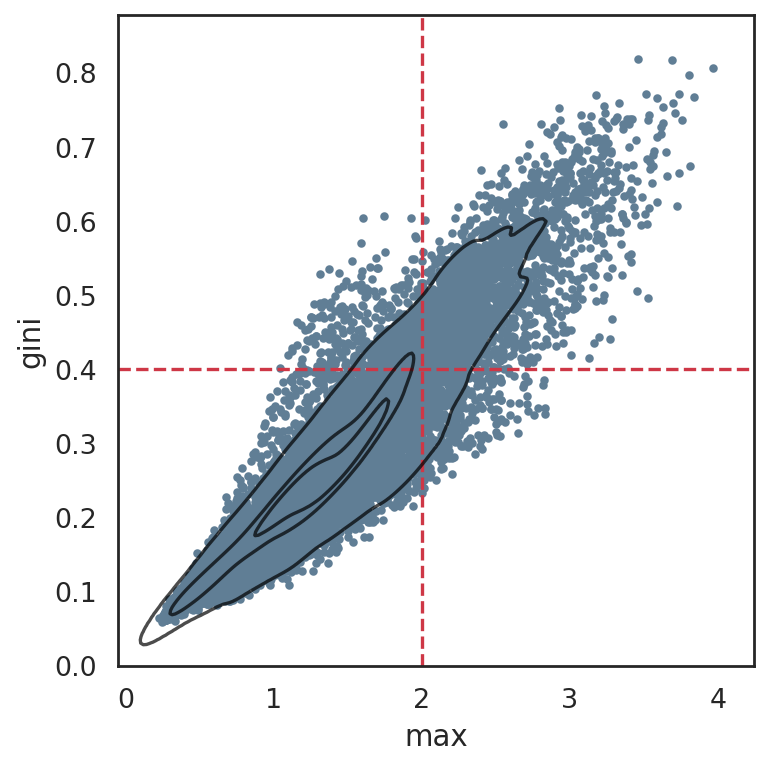

In [36]:
si.pl.entity_metrics(adata_cmp_CG,x='max',y='gini',
                     show_texts=False,
                     show_cutoff=True,
                     show_contour=True,
                     c='#607e95',
                     cutoff_x=2,
                     cutoff_y=0.4)

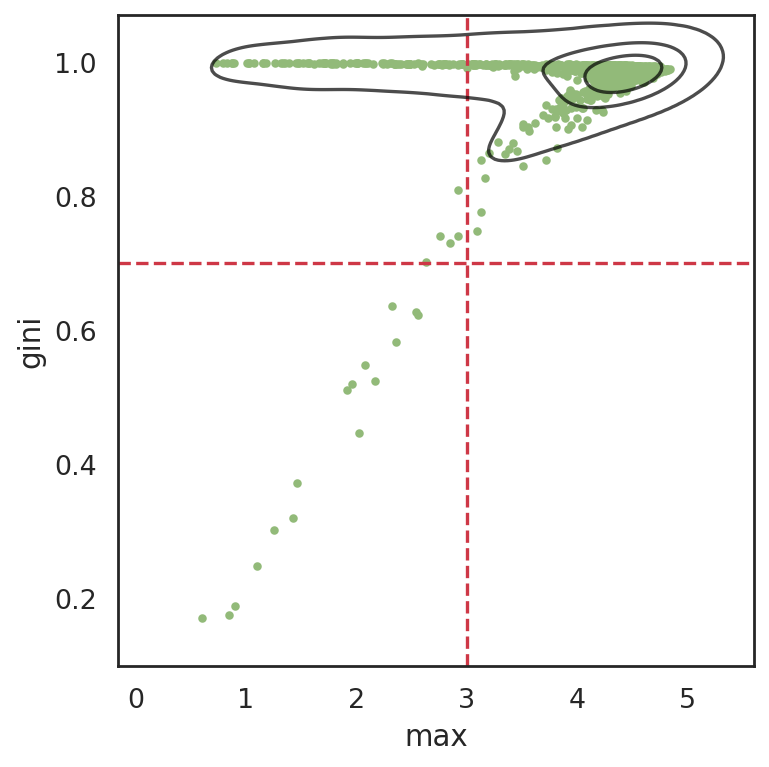

In [37]:
si.pl.entity_metrics(adata_cmp_CM,x='max',y='gini',
                     show_texts=False,
                     show_cutoff=True,
                     show_contour=True,
                     c='#92ba79',
                     cutoff_x=3,
                     cutoff_y=0.7)

## Identify master regulators

In [38]:
# --- Diagnostic prints ---
print("\n--- Debugging `adata_all.obs` columns ---")
print("Columns in adata_all.obs:", adata_all.obs.columns.tolist())
print("'entity_anno' column exists:", 'entity_anno' in adata_all.obs.columns)

if 'entity_anno' in adata_all.obs.columns:
    print("\nValue counts for 'entity_anno' (first 10 if too many unique values):")
    print(adata_all.obs['entity_anno'].value_counts().head(10))
    print("\nHead of adata_all.obs['entity_anno']:")
    print(adata_all.obs['entity_anno'].head())
    print("\nTail of adata_all.obs['entity_anno']:")
    print(adata_all.obs['entity_anno'].tail())
else:
    print("\nPROBLEM: 'entity_anno' column is missing from adata_all.obs!")
print("-" * 30)



--- Debugging `adata_all.obs` columns ---
Columns in adata_all.obs: ['seurat_clusters', 'time_point', 'celltype', 'clone_line', 'Genotype', 'id_dataset']
'entity_anno' column exists: False

PROBLEM: 'entity_anno' column is missing from adata_all.obs!
------------------------------


### add entity anno to adata_all

In [39]:
## add annotations of all entities
adata_all.obs['entity_anno'] = ""
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'seurat_clusters'].tolist()
adata_all.obs.loc[adata_G.obs_names, 'entity_anno'] = 'gene'
adata_all.obs.loc[adata_P.obs_names, 'entity_anno'] = 'peak'
adata_all.obs.loc[adata_K.obs_names, 'entity_anno'] = 'kmer'
adata_all.obs.loc[adata_M.obs_names, 'entity_anno'] = 'motif'

In [40]:
adata_all.obs.head()


,seurat_clusters,time_point,celltype,clone_line,Genotype,id_dataset,entity_anno
MCO_1280_TTTCACCCATTAGCGC-1,3,72_hours,2.0,Del_80bp_2,Del_80bp,ref,3
MCO_1279_CTCGACAAGGACAACA-1,3,48_hours,2.0,rs139141690_2,rs139141690,ref,3
MCO_1279_CAGAACCGTTTATCGC-1,5,48_hours,1.0,wt_3,wt,ref,5
MCO_1280_GGGCTAACATTAAGTC-1,2,72_hours,0.0,Del_16bp_1,Del_16bp,ref,2
MCO_1281_CGCATATAGGATAAAC-1,2,96_hours,0.0,Del_16bp_1,Del_16bp,ref,2


In [41]:
df_MR = si.tl.find_master_regulators(adata_all,
                                     list_tf_motif=list_tf_motif,
                                     list_tf_gene=list_tf_gene,
                                     cutoff_gene_max=2,
                                     cutoff_gene_gini=0.4,
                                     cutoff_motif_max=3,
                                     cutoff_motif_gini=0.7,
                                     metrics_gene=df_metrics_gene,
                                     metrics_motif=df_metrics_motif
                                    )

Adding motif metrics ...
Adding gene metrics ...
Computing distances between TF motifs and genes ...
filtering master regulators based on gene metrics:
Gini index
max
filtering master regulators based on motif metrics:
Gini index
max


/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/simba/tools/_post_training.py:619: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.367044979346499' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_MR.loc[i, 'dist'] = dist_MG.loc[x_motif, x_gene]


In [42]:
print("--- Head of df_MR ---")
print(df_MR.head())

print("\n--- Shape of df_MR ---")
print(df_MR.shape)

--- Head of df_MR ---
Empty DataFrame
Columns: [motif, gene, rank, dist, max_motif, std_motif, gini_motif, entropy_motif, max_gene, std_gene, gini_gene, entropy_gene]
Index: []

--- Shape of df_MR ---
(0, 12)


## Identify target genes

## make sure the indices of motifs are the same as in `motifs_genes_unique`

In [43]:
adata_PM.var.index = 'M_' + adata_PM.var.index

## get the overlap between peaks and gene loci

In [44]:
reference_genome = '/processing_data/reference_datasets/iGenomes/2022.1/Homo_sapiens/NCBI/GRCh38/Sequence/WholeGenomeFasta/genome.fa'

In [45]:
adata_CP

AnnData object with n_obs × n_vars = 11250 × 356772
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblF

In [46]:
adata_CP.var_names

Index(['chr1-10063-10371', 'chr1-17238-17447', 'chr1-115501-115774',
       'chr1-138879-139097', 'chr1-180694-181047', 'chr1-181290-181588',
       'chr1-184068-184460', 'chr1-191239-191551', 'chr1-605114-605610',
       'chr1-629563-630703',
       ...
       'chrY-56857390-56858213', 'chrY-56858577-56859056',
       'chrY-56860234-56860510', 'chrY-56861341-56861666',
       'chrY-56869643-56870178', 'chrY-56870723-56871184',
       'chrY-56873548-56874117', 'chrY-56875917-56876293',
       'chrY-56877514-56877843', 'chrY-56879608-56880130'],
      dtype='object', length=356772)

### Print the first few to see the format

In [47]:
adata_CP.var_names[:5].to_list()

['chr1-10063-10371',
 'chr1-17238-17447',
 'chr1-115501-115774',
 'chr1-138879-139097',
 'chr1-180694-181047']

### Extrat chr start and end as separate columns in ann data

In [48]:
# Split var_names into chrosome, start, and end positions
adata_CP.var[['chr', 'start', 'end']] = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')


In [49]:
adata_CP.var[['chrom']]

,chrom
chr1-10063-10371,chr1
chr1-17238-17447,chr1
chr1-115501-115774,chr1
chr1-138879-139097,chr1
chr1-180694-181047,chr1
...,...
chrY-56870723-56871184,chrY
chrY-56873548-56874117,chrY
chrY-56875917-56876293,chrY
chrY-56877514-56877843,chrY


In [50]:
matched = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')

matched


,0,1,2
0,chr1,10063,10371
1,chr1,17238,17447
2,chr1,115501,115774
3,chr1,138879,139097
4,chr1,180694,181047
...,...,...,...
356767,chrY,56870723,56871184
356768,chrY,56873548,56874117
356769,chrY,56875917,56876293
356770,chrY,56877514,56877843


In [51]:
# Check rows where it failed
bad_rows = adata_CP.var_names[matched.isnull().any(axis=1)]
bad_rows[:10].to_list()  # Print first few problem entries

[]

In [52]:
matched.keys

<bound method NDFrame.keys of            0         1         2
0       chr1     10063     10371
1       chr1     17238     17447
2       chr1    115501    115774
3       chr1    138879    139097
4       chr1    180694    181047
...      ...       ...       ...
356767  chrY  56870723  56871184
356768  chrY  56873548  56874117
356769  chrY  56875917  56876293
356770  chrY  56877514  56877843
356771  chrY  56879608  56880130

[356772 rows x 3 columns]>

In [53]:
# Extract chromosome, start, end from var_names
adata_CP.var[['chrom', 'start', 'end']] = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')


In [54]:
adata_CP.var[['chrom', 'start', 'end']].head()


,chrom,start,end
chr1-10063-10371,NaN,NaN,NaN
chr1-17238-17447,NaN,NaN,NaN
chr1-115501-115774,NaN,NaN,NaN
chr1-138879-139097,NaN,NaN,NaN
chr1-180694-181047,NaN,NaN,NaN


In [55]:
print(type(adata_CP.var_names))

<class 'pandas.core.indexes.base.Index'>


#### Convert index

In [56]:
var_names_str = adata_CP.var_names.astype(str)

var_names_str

Index(['chr1-10063-10371', 'chr1-17238-17447', 'chr1-115501-115774',
       'chr1-138879-139097', 'chr1-180694-181047', 'chr1-181290-181588',
       'chr1-184068-184460', 'chr1-191239-191551', 'chr1-605114-605610',
       'chr1-629563-630703',
       ...
       'chrY-56857390-56858213', 'chrY-56858577-56859056',
       'chrY-56860234-56860510', 'chrY-56861341-56861666',
       'chrY-56869643-56870178', 'chrY-56870723-56871184',
       'chrY-56873548-56874117', 'chrY-56875917-56876293',
       'chrY-56877514-56877843', 'chrY-56879608-56880130'],
      dtype='object', length=356772)

#### Create a separate table with the extraction of the fields

In [57]:
test = var_names_str.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')

test.columns = ['chr', 'start', 'end']
test.index = adata_CP.var_names

print(test[:5]) 

                     chr   start     end
chr1-10063-10371    chr1   10063   10371
chr1-17238-17447    chr1   17238   17447
chr1-115501-115774  chr1  115501  115774
chr1-138879-139097  chr1  138879  139097
chr1-180694-181047  chr1  180694  181047


#### Assign the table to the columns

In [58]:
adata_CP.var[['chr', 'start', 'end']] = test

In [61]:
adata_CP.var[['chr', 'start', 'end']]

,chr,start,end
chr1-10063-10371,chr1,10063,10371
chr1-17238-17447,chr1,17238,17447
chr1-115501-115774,chr1,115501,115774
chr1-138879-139097,chr1,138879,139097
chr1-180694-181047,chr1,180694,181047
...,...,...,...
chrY-56870723-56871184,chrY,56870723,56871184
chrY-56873548-56874117,chrY,56873548,56874117
chrY-56875917-56876293,chrY,56875917,56876293
chrY-56877514-56877843,chrY,56877514,56877843


#### change start and end to integers

In [62]:
adata_CP.var[['start', 'end']] = adata_CP.var[['start', 'end']].astype(int)

## Create the dict of tf targets

In [64]:
dict_tf_targets = si.tl.find_target_genes(adata_all,
                                          adata_PM,
                                          list_tf_motif=list_tf_motif,
                                          list_tf_gene=list_tf_gene,
                                          adata_CP=adata_CP)

Preprocessing ...
#genes: 30028
#peaks: 713544
#genes-associated peaks: 337606
computing distances between genes and genes-associated peaks ...
Saving variables into `.uns['tf_targets']` ...
searching for target genes of M_CUX1
#candinate genes is 400
removing duplicate genes ...
removing genes that do not contain TF motif ...
#candinate genes is 128
completed: 0.0%
completed: 19.5%
completed: 39.1%
completed: 58.6%
completed: 78.1%
completed: 97.7%
Pruning candidate genes based on nearby peaks ...
searching for target genes of M_RUNX1
#candinate genes is 400
removing duplicate genes ...
removing genes that do not contain TF motif ...
#candinate genes is 251
completed: 0.0%
completed: 19.9%
completed: 39.8%
completed: 59.8%
completed: 79.7%
completed: 99.6%
Pruning candidate genes based on nearby peaks ...


## Check the keys

In [65]:
dict_tf_targets.keys()

dict_keys(['M_CUX1', 'M_RUNX1'])

In [66]:
matches = [key for key in dict_tf_targets.keys() if "RUNX1" in key]

matches

['M_RUNX1']

In [67]:
matches = [key for key in dict_tf_targets.keys() if "CUX1" in key]

matches

['M_CUX1']

In [68]:
type(dict_tf_targets)

dict

In [69]:
value = dict_tf_targets.get("M_RUNX1")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene
TRPC4AP,9481.0,yes,18788,174,853,853,109,109
ARID4B,9674.5,yes,19224,125,113,17752,774,774
PUM2,9920.0,yes,19743,97,19095,19095,134,134
GLG1,10039.5,yes,19975,104,597,19864,4348,4348
LPIN2,10046.0,yes,19895,197,322,10095,11348,11348
...,...,...,...,...,...,...,...,...
LINC02452,14849.5,yes,143,29556,741,741,1673,1673
CELF2-AS2,14906.0,yes,114,29698,49,49,44,44
ADCY6-DT,14983.5,yes,53,29914,511,68165,936,936
NXNL1,15009.5,yes,8,30011,398,132680,512,512


In [70]:
value = dict_tf_targets.get("M_CUX1")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene
PUM2,10026.5,yes,19922,131,23790,329306,134,134
SENP6,10093.0,yes,20004,182,14911,18982,202,202
CHD9,10184.5,yes,20339,30,954,107601,2092,2092
FAF1,10242.0,yes,20345,139,1825,8503,470,470
POLK,10346.5,yes,20496,197,7856,45667,996,996
KIAA0232,10460.0,yes,20720,200,3452,49355,656,656
DNAJC1,10515.5,yes,20918,113,2842,5435,816,816
RNGTT,10599.5,yes,21030,169,52,82715,29206,29206
COMMD10,10607.0,yes,21044,170,10154,28856,681,681
SLMAP,10758.0,yes,21428,88,534,31112,1090,1090


In [71]:
value = dict_tf_targets.get("M_GATA1")

value

In [72]:
print("\n--- Debugging adata_CP.var['chrom'] ---")

# Check if 'chrom' column exists
if 'chrom' in adata_CP.var.columns:
    chrom_series = adata_CP.var['chrom']
    print(f"Data type of 'chrom' column: {chrom_series.dtype}")
    print("\nValue counts for 'chrom' column:")
    print(chrom_series.value_counts(dropna=False).head()) # Check values and NaNs
    print("\nUnique values and their types in 'chrom' column (first 10, or all if less):")
    unique_types = set()
    for val in chrom_series.dropna().unique(): # Iterate unique non-NaN values
        unique_types.add(type(val))
    print(unique_types)

    # Find specific non-string elements if any
    non_string_elements = chrom_series[~chrom_series.apply(lambda x: isinstance(x, (str, bytes)) or pd.isna(x))]
    if not non_string_elements.empty:
        print("\nFound non-string, non-NaN elements in 'chrom' column:")
        print(non_string_elements.head())
    else:
        print("\nAll non-NaN elements in 'chrom' column appear to be strings or bytes.")
else:
    print("Error: 'chrom' column not found in adata_CP.var!")

print("-" * 30)


--- Debugging adata_CP.var['chrom'] ---
Data type of 'chrom' column: object

Value counts for 'chrom' column:
chrom
NaN    356772
Name: count, dtype: int64

Unique values and their types in 'chrom' column (first 10, or all if less):
set()

All non-NaN elements in 'chrom' column appear to be strings or bytes.
------------------------------


In [73]:
print("\n--- Debugging adata_CP.var['chr'] ---")

# Check if 'chr' column exists
if 'chr' in adata_CP.var.columns:
    chr_series = adata_CP.var['chr']
    print(f"Data type of 'chr' column: {chr_series.dtype}")
    print("\nValue counts for 'chr' column:")
    print(chr_series.value_counts(dropna=False).head()) # Check values and NaNs
    print("\nUnique values and their types in 'chr' column (first 10, or all if less):")
    unique_types = set()
    for val in chr_series.dropna().unique(): # Iterate unique non-NaN values
        unique_types.add(type(val))
    print(unique_types)

    # Find specific non-string elements if any
    non_string_elements = chr_series[~chr_series.apply(lambda x: isinstance(x, (str, bytes)) or pd.isna(x))]
    if not non_string_elements.empty:
        print("\nFound non-string, non-NaN elements in 'chr' column:")
        print(non_string_elements.head())
    else:
        print("\nAll non-NaN elements in 'chr' column appear to be strings or bytes.")
else:
    print("Error: 'chr' column not found in adata_CP.var!")

print("-" * 30)


--- Debugging adata_CP.var['chr'] ---
Data type of 'chr' column: object

Value counts for 'chr' column:
chr
chr1    35039
chr2    29956
chr6    24212
chr3    22472
chr7    21681
Name: count, dtype: int64

Unique values and their types in 'chr' column (first 10, or all if less):
{<class 'str'>}

All non-NaN elements in 'chr' column appear to be strings or bytes.
------------------------------


# SAVE RESULTS

In [74]:
with open('/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/dict_tf_targets_only_CUX1_RUNX1.pickle', 'wb') as handle:
    pickle.dump(dict_tf_targets, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Read it back

In [13]:
with open('/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/dict_tf_targets_only_CUX1_RUNX1.pickle', 'rb') as handle:
    dict_tf_targets = pickle.load(handle)

In [14]:
dict_tf_targets.keys()

dict_keys(['M_CUX1', 'M_RUNX1'])

# Export the genes GRN CUX1

In [15]:
retrieved_list = dict_tf_targets.get("M_CUX1")

print(f"DEBUG: Type of retrieved_list: {type(retrieved_list)}")
#print(f"DEBUG: Content of retrieved_list: {retrieved_list}")


DEBUG: Type of retrieved_list: <class 'pandas.core.frame.DataFrame'>


In [16]:
print(f"DEBUG: Type of value_df: {type(retrieved_list)}")
print(f"DEBUG: Columns of value_df: {retrieved_list.columns.tolist()}") # Check current column names
print(f"DEBUG: Index of value_df: {retrieved_list.index.tolist()}") # The gene names are here!

if retrieved_list is not None:
    # The gene names are in the DataFrame's index.
    # To convert the index to a column:
    GRN_CUX1_df = retrieved_list.index.to_frame(name='Gene_Name')

    # If you just want the Series of gene names:
    # gene_names_series = value_df.index.to_series(name='Gene_Name')
    # Or simply:
    # gene_names_series = pd.Series(value_df.index, name='Gene_Name')

    print("\nSuccessfully created GRN_CUX1_df:")
    print(GRN_CUX1_df)

    print("\nFinal columns of GRN_CUX1_df:")
    print(GRN_CUX1_df.columns)

else:
    print("Error: 'M_CUX1' key not found in dict_tf_targets, or its value is None.")
    GRN_CUX1_df = pd.DataFrame(columns=['Gene_Name']) # Create an empty DataFrame

DEBUG: Type of value_df: <class 'pandas.core.frame.DataFrame'>
DEBUG: Columns of value_df: ['average_rank', 'has_motif', 'rank_gene_to_TFmotif', 'rank_gene_to_TFgene', 'rank_peak_to_TFmotif', 'rank_peak2_to_TFmotif', 'rank_peak_to_gene', 'rank_peak2_to_gene']
DEBUG: Index of value_df: ['PUM2', 'SENP6', 'CHD9', 'FAF1', 'POLK', 'KIAA0232', 'DNAJC1', 'RNGTT', 'COMMD10', 'SLMAP', 'SLC25A13', 'CNOT4', 'SSH2', 'CD2AP', 'NFAT5', 'PAN3', 'CDKAL1', 'NF1', 'STK3', 'CUX1', 'TLK1', 'VTI1A', 'ABL1', 'ANO10', 'ZNF148', 'CCDC91', 'CYTOR', 'ANKRD17', 'RPL23A', 'SLC25A21', 'ERBIN', 'PRKCA', 'EHMT1', 'SMYD3', 'JMJD1C', 'AGAP1', 'RERE', 'ARHGAP6', 'MIR4435-2HG', 'IMMP2L']

Successfully created GRN_CUX1_df:
               Gene_Name
PUM2                PUM2
SENP6              SENP6
CHD9                CHD9
FAF1                FAF1
POLK                POLK
KIAA0232        KIAA0232
DNAJC1            DNAJC1
RNGTT              RNGTT
COMMD10          COMMD10
SLMAP              SLMAP
SLC25A13        SLC25A13
CNO

In [17]:
type(GRN_CUX1_df)


pandas.core.frame.DataFrame

In [18]:
GRN_CUX1_df.shape

(40, 1)

In [19]:
GRN_CUX1_df['Motif_Group'] = 'GRN_CUX1'

print("\nUpdated GRN_CUX1_df with 'Motif_Group' column:")
print(GRN_CUX1_df)


Updated GRN_CUX1_df with 'Motif_Group' column:
               Gene_Name Motif_Group
PUM2                PUM2    GRN_CUX1
SENP6              SENP6    GRN_CUX1
CHD9                CHD9    GRN_CUX1
FAF1                FAF1    GRN_CUX1
POLK                POLK    GRN_CUX1
KIAA0232        KIAA0232    GRN_CUX1
DNAJC1            DNAJC1    GRN_CUX1
RNGTT              RNGTT    GRN_CUX1
COMMD10          COMMD10    GRN_CUX1
SLMAP              SLMAP    GRN_CUX1
SLC25A13        SLC25A13    GRN_CUX1
CNOT4              CNOT4    GRN_CUX1
SSH2                SSH2    GRN_CUX1
CD2AP              CD2AP    GRN_CUX1
NFAT5              NFAT5    GRN_CUX1
PAN3                PAN3    GRN_CUX1
CDKAL1            CDKAL1    GRN_CUX1
NF1                  NF1    GRN_CUX1
STK3                STK3    GRN_CUX1
CUX1                CUX1    GRN_CUX1
TLK1                TLK1    GRN_CUX1
VTI1A              VTI1A    GRN_CUX1
ABL1                ABL1    GRN_CUX1
ANO10              ANO10    GRN_CUX1
ZNF148            ZNF148   

# Export the genes GRN RUNX1

In [20]:
retrieved_list = dict_tf_targets.get("M_RUNX1")

print(f"DEBUG: Type of retrieved_list: {type(retrieved_list)}")
#print(f"DEBUG: Content of retrieved_list: {retrieved_list}")


DEBUG: Type of retrieved_list: <class 'pandas.core.frame.DataFrame'>


In [21]:
retrieved_list

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene
TRPC4AP,9481.0,yes,18788,174,853,853,109,109
ARID4B,9674.5,yes,19224,125,113,17752,774,774
PUM2,9920.0,yes,19743,97,19095,19095,134,134
GLG1,10039.5,yes,19975,104,597,19864,4348,4348
LPIN2,10046.0,yes,19895,197,322,10095,11348,11348
...,...,...,...,...,...,...,...,...
LINC02452,14849.5,yes,143,29556,741,741,1673,1673
CELF2-AS2,14906.0,yes,114,29698,49,49,44,44
ADCY6-DT,14983.5,yes,53,29914,511,68165,936,936
NXNL1,15009.5,yes,8,30011,398,132680,512,512


In [22]:
print(f"DEBUG: Type of value_df: {type(retrieved_list)}")
print(f"DEBUG: Columns of value_df: {retrieved_list.columns.tolist()}") # Check current column names
print(f"DEBUG: Index of value_df: {retrieved_list.index.tolist()}") # The gene names are here!

if retrieved_list is not None:
    # The gene names are in the DataFrame's index.
    # To convert the index to a column:
    GRN_RUNX1_df = retrieved_list.index.to_frame(name='Gene_Name')

    # If you just want the Series of gene names:
    # gene_names_series = value_df.index.to_series(name='Gene_Name')
    # Or simply:
    # gene_names_series = pd.Series(value_df.index, name='Gene_Name')

    print("\nSuccessfully created GRN_RUNX1_df:")
    print(GRN_RUNX1_df)

    print("\nFinal columns of GRN_RUNX1_df:")
    print(GRN_RUNX1_df.columns)

else:
    print("Error: 'M_CUX1' key not found in dict_tf_targets, or its value is None.")
    GRN_RUNX1_df = pd.DataFrame(columns=['Gene_Name']) # Create an empty DataFrame

DEBUG: Type of value_df: <class 'pandas.core.frame.DataFrame'>
DEBUG: Columns of value_df: ['average_rank', 'has_motif', 'rank_gene_to_TFmotif', 'rank_gene_to_TFgene', 'rank_peak_to_TFmotif', 'rank_peak2_to_TFmotif', 'rank_peak_to_gene', 'rank_peak2_to_gene']
DEBUG: Index of value_df: ['TRPC4AP', 'ARID4B', 'PUM2', 'GLG1', 'LPIN2', 'COMMD10', 'CHD9', 'SSH2', 'KIAA0232', 'UPF2', 'TOP1', 'DNAJC1', 'PIP4K2A', 'ASH1L', 'SLMAP', 'UBXN4', 'NFAT5', 'RPS15', 'CHST11', 'ABI1', 'MSH3', 'FRMD8', 'TRMT11', 'NF1', 'SNX14', 'EPC2', 'PDLIM5', 'SRSF4', 'CNOT4', 'RNGTT', 'NFATC3', 'CAPZA1', 'RUNX1', 'RIPK1', 'TMEM167A', 'FUCA2', 'CALN1', 'LIMS1', 'ZNF518A', 'GATAD2A', 'RBM39', 'ANO10', 'MTDH', 'UPF3A', 'RHOBTB3', 'ZMYM4', 'CHD4', 'TCF12', 'RPL23A', 'EXOC6', 'RPS15A', 'SS18', 'GALK2', 'CHCHD2', 'WAC', 'ERBIN', 'CALU', 'COG5', 'UBA6-AS1', 'MTOR', 'SPAG9', 'LINC02452', 'CELF2-AS2', 'ADCY6-DT', 'NXNL1', 'LINC01180']

Successfully created GRN_RUNX1_df:
           Gene_Name
TRPC4AP      TRPC4AP
ARID4B        

In [23]:
type(GRN_RUNX1_df)


pandas.core.frame.DataFrame

In [24]:
GRN_RUNX1_df.shape

(66, 1)

In [25]:
GRN_RUNX1_df['Motif_Group'] = 'GRN_RUNX1'

print("\nUpdated GRN_RUNX1_df with 'Motif_Group' column:")
print(GRN_RUNX1_df)


Updated GRN_RUNX1_df with 'Motif_Group' column:
           Gene_Name Motif_Group
TRPC4AP      TRPC4AP   GRN_RUNX1
ARID4B        ARID4B   GRN_RUNX1
PUM2            PUM2   GRN_RUNX1
GLG1            GLG1   GRN_RUNX1
LPIN2          LPIN2   GRN_RUNX1
...              ...         ...
LINC02452  LINC02452   GRN_RUNX1
CELF2-AS2  CELF2-AS2   GRN_RUNX1
ADCY6-DT    ADCY6-DT   GRN_RUNX1
NXNL1          NXNL1   GRN_RUNX1
LINC01180  LINC01180   GRN_RUNX1

[66 rows x 2 columns]


# combine data frames and export as tsv

In [27]:
combined_vertical_df = pd.concat([GRN_CUX1_df, GRN_RUNX1_df], ignore_index=True)

combined_vertical_df.shape

combined_vertical_df

,Gene_Name,Motif_Group
0,PUM2,GRN_CUX1
1,SENP6,GRN_CUX1
2,CHD9,GRN_CUX1
3,FAF1,GRN_CUX1
4,POLK,GRN_CUX1
...,...,...
101,LINC02452,GRN_RUNX1
102,CELF2-AS2,GRN_RUNX1
103,ADCY6-DT,GRN_RUNX1
104,NXNL1,GRN_RUNX1


In [155]:
# --- Define the output filename ---
output_filename = 'GRN_target_genes_CUX1_RUNX1.tsv'

# --- Combine the directory path and the filename ---
full_output_path = os.path.join(workdir, output_filename)

# --- Export the DataFrame ---
combined_vertical_df.to_csv(full_output_path, sep='\t', index=False)

print(f"DataFrame successfully exported to '{full_output_path}'")

DataFrame successfully exported to '/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/GRN_target_genes_CUX1_RUNX1.tsv'


# Find selected peaks with motifs

## Read input data

In [10]:
workdir = '/group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/'
si.settings.set_workdir(workdir)

Saving results in: /group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba/result_SIMBA/


In [11]:

adata_CP = si.read_h5ad(os.path.join(workdir,'adata_CP.h5ad'))

adata_CP

AnnData object with n_obs × n_vars = 11250 × 356772
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblF

In [40]:
adata_PM = si.read_h5ad(os.path.join(workdir,'adata_PM.h5ad'))

adata_PM

AnnData object with n_obs × n_vars = 356772 × 1069
    var: 'original_var_names'

In [47]:
adata_PM.obs

# Check the first few and last few observation names (Peak IDs) in adata_PM
print("First 5 observation names (Peak IDs) in adata_PM:")
print(adata_PM.obs_names[:5].tolist()) # .tolist() to print clearly

print("\nLast 5 observation names (Peak IDs) in adata_PM:")
print(adata_PM.obs_names[-5:].tolist()) # .tolist() to print clearly

First 5 observation names (Peak IDs) in adata_PM:
['chr1_10063_10371', 'chr1_17238_17447', 'chr1_115501_115774', 'chr1_138879_139097', 'chr1_180694_181047']

Last 5 observation names (Peak IDs) in adata_PM:
['chrY_56870723_56871184', 'chrY_56873548_56874117', 'chrY_56875917_56876293', 'chrY_56877514_56877843', 'chrY_56879608_56880130']


In [51]:
print("First 20 names of variables (columns) in adata_PM (potential motif names):")
print(adata_PM.var['original_var_names'].head(20).tolist())

print("\nLast 20 names of variables (columns) in adata_PM:")
print(adata_PM.var['original_var_names'].tail(20).tolist())

First 20 names of variables (columns) in adata_PM (potential motif names):
['FOXF2', 'FOXD1', 'IRF2', 'MZF1(var.2)', 'MAX_MYC', 'PPARG', 'PAX6', 'PBX1', 'RORA', 'RORA(var.2)', 'RREB1', 'RXRA_VDR', 'SOX9', 'SRY', 'TAL1_TCF3', 'REL', 'RELA', 'NR1H2_RXRA', 'NFIC_TLX1', 'ZNF354C']

Last 20 names of variables (columns) in adata_PM:
['Znf263(Zf)/K562-Znf263-ChIP-Seq(GSE31477)/Homer', 'ZNF264(Zf)/HEK293-ZNF264.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF317(Zf)/HEK293-ZNF317.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF322(Zf)/HEK293-ZNF322.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF341(Zf)/EBV-ZNF341-ChIP-Seq(GSE113194)/Homer', 'ZNF382(Zf)/HEK293-ZNF382.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF415(Zf)/HEK293-ZNF415.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF416(Zf)/HEK293-ZNF416.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF41(Zf)/HEK293-ZNF41.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF467(Zf)/HEK293-ZNF467.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF519(Zf)/HEK293-ZNF519.GFP-ChIP-Seq(GSE58341)/Homer', 'ZNF528(Zf)/HEK293-ZNF528.GFP-ChIP-Seq(GSE58341)/Homer', 

## Define genes to retrieve

In [36]:
# 1. Get the unique gene names from the 'Gene_Name' column of combined_vertical_df
genes_to_retrieve = combined_vertical_df['Gene_Name'].unique().tolist()

#genes_to_retrieve

## Get the gene scores from adata_CP

In [37]:
# 2. Access the 'gene_scores' dictionary from adata_CP.uns
gene_scores_dict = adata_CP.uns.get('gene_scores')

gene_scores_dict

{'overlap':         chr_p   start_p     end_p    id_p chr_g   start_g     end_g  \
 0        chr1     10063     10371       0  chr1         0    100000   
 1        chr1     10063     10371       0  chr1         0    100000   
 2        chr1     10063     10371       0  chr1         0    100000   
 3        chr1     10063     10371       0  chr1         0    117436   
 4        chr1     10063     10371       0  chr1         0    100000   
 ...       ...       ...       ...     ...   ...       ...       ...   
 1077396  chrY  56870723  56871184  356767  chrY  56854254  56968979   
 1077397  chrY  56873548  56874117  356768  chrY  56854254  56968979   
 1077398  chrY  56875917  56876293  356769  chrY  56854254  56968979   
 1077399  chrY  56877514  56877843  356770  chrY  56854254  56968979   
 1077400  chrY  56879608  56880130  356771  chrY  56854254  56968979   
 
             symbol_g  score_g strand_g   id_g     dist  
 0            DDX11L1        0        +   4830      0.0  
 1     

## overlap between both

In [35]:
if gene_scores_dict is None:
    print("Error: 'gene_scores' not found in adata_CP.uns. Please ensure `simba.tl.gene_scores` was run.")
else:
    # 3. Check if the 'overlap' DataFrame exists within 'gene_scores'
    if 'overlap' in gene_scores_dict:
        peak_gene_overlap_df = gene_scores_dict['overlap']

        # 4. Filter the peak_gene_overlap_df for the genes in genes_to_retrieve
        # We're assuming the gene column in peak_gene_overlap_df is named 'gene'.
        # If it's named something else, please adjust 'gene' below.
        peaks_with_scores_for_selected_genes = peak_gene_overlap_df[
            peak_gene_overlap_df['symbol_g'].isin(genes_to_retrieve)
        ]

        print(f"Retrieved {len(peaks_with_scores_for_selected_genes)} peak-gene associations "
              f"for {len(genes_to_retrieve)} genes from `combined_vertical_df`.")
        print("\nFirst 10 rows of peaks with gene scores for the selected genes:")
        print(peaks_with_scores_for_selected_genes.head(10))

        print(f"\nColumns in the retrieved DataFrame: {peaks_with_scores_for_selected_genes.columns.tolist()}")

        

    else:
        print("The 'gene_scores' dictionary does not contain an 'overlap' key. "
              "Please inspect `adata_CP.uns['gene_scores'].keys()` to find the correct key "
              "that stores the peak-gene mapping.")

Retrieved 5726 peak-gene associations for 92 genes from `combined_vertical_df`.

First 10 rows of peaks with gene scores for the selected genes:
     chr_p  start_p    end_p  id_p chr_g  start_g    end_g symbol_g  score_g  \
6018  chr1  8357282  8357919  1348  chr1  8352403  8917640     RERE        0   
6020  chr1  8358756  8359622  1349  chr1  8352403  8917640     RERE        0   
6022  chr1  8372230  8372580  1350  chr1  8352403  8917640     RERE        0   
6024  chr1  8373579  8373786  1351  chr1  8352403  8917640     RERE        0   
6026  chr1  8374473  8375094  1352  chr1  8352403  8917640     RERE        0   
6028  chr1  8378333  8378535  1353  chr1  8352403  8917640     RERE        0   
6030  chr1  8379379  8380108  1354  chr1  8352403  8917640     RERE        0   
6032  chr1  8380965  8381263  1355  chr1  8352403  8917640     RERE        0   
6034  chr1  8384110  8384785  1356  chr1  8352403  8917640     RERE        0   
6036  chr1  8388806  8390240  1357  chr1  8352403  8917

In [38]:
peaks_with_scores_for_selected_genes.shape

(5726, 12)

## Create Peak_ID

In [48]:
peaks_with_scores_for_selected_genes['Peak_ID'] = (
    peaks_with_scores_for_selected_genes['chr_p'].astype(str) + '_' +
    peaks_with_scores_for_selected_genes['start_p'].astype(str) + '_' +
    peaks_with_scores_for_selected_genes['end_p'].astype(str)
)

print("First 10 rows of the DataFrame with the new 'Peak_ID' column:")
print(peaks_with_scores_for_selected_genes.head(10))

First 10 rows of the DataFrame with the new 'Peak_ID' column:
     chr_p  start_p    end_p  id_p chr_g  start_g    end_g symbol_g  score_g  \
6018  chr1  8357282  8357919  1348  chr1  8352403  8917640     RERE        0   
6020  chr1  8358756  8359622  1349  chr1  8352403  8917640     RERE        0   
6022  chr1  8372230  8372580  1350  chr1  8352403  8917640     RERE        0   
6024  chr1  8373579  8373786  1351  chr1  8352403  8917640     RERE        0   
6026  chr1  8374473  8375094  1352  chr1  8352403  8917640     RERE        0   
6028  chr1  8378333  8378535  1353  chr1  8352403  8917640     RERE        0   
6030  chr1  8379379  8380108  1354  chr1  8352403  8917640     RERE        0   
6032  chr1  8380965  8381263  1355  chr1  8352403  8917640     RERE        0   
6034  chr1  8384110  8384785  1356  chr1  8352403  8917640     RERE        0   
6036  chr1  8388806  8390240  1357  chr1  8352403  8917640     RERE        0   

     strand_g   id_g  dist               Peak_ID  
6018  

/localscratch/21406878.manuel.tardaguila/ipykernel_2615488/3724951388.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peaks_with_scores_for_selected_genes['Peak_ID'] = (


## Get the motifs for my Peak_IDs

In [52]:
# 1. Get the list of Peak_IDs from your peaks_with_scores_for_selected_genes DataFrame
target_peak_ids = peaks_with_scores_for_selected_genes['Peak_ID'].unique().tolist()

# 2. Filter adata_PM to include only the selected peaks
# It's good practice to ensure the IDs exist in adata_PM.obs_names first
peaks_in_adata_PM = adata_PM.obs_names.intersection(target_peak_ids)

if len(peaks_in_adata_PM) == 0:
    print("Warning: None of the target Peak_IDs found in adata_PM.obs_names.")
    print("Please double-check if the Peak_ID format in your DataFrame matches adata_PM.obs_names exactly.")
else:
    # Select the relevant peaks from adata_PM
    # The [peaks_in_adata_PM, :] syntax slices by observation names (rows) and keeps all variables (columns)
    adata_PM_filtered_for_target_peaks = adata_PM[peaks_in_adata_PM, :].copy()

    print(f"\nFiltered adata_PM object containing {len(peaks_in_adata_PM)} selected peaks:")
    print(adata_PM_filtered_for_target_peaks)

    # 3. Extract the motif scores from the .X matrix
    # Convert the potentially sparse matrix to a dense NumPy array, then to a DataFrame
    motif_scores_matrix = adata_PM_filtered_for_target_peaks.X.toarray()

    # Create a DataFrame with peaks as index and motif names as columns
    motif_scores_df = pd.DataFrame(
        motif_scores_matrix,
        index=adata_PM_filtered_for_target_peaks.obs_names,
        columns=adata_PM_filtered_for_target_peaks.var_names # These are your motif names
    )

    print("\nMotif scores for the selected peaks (first 5 rows, first 5 motifs):")
    print(motif_scores_df.iloc[:5, :5]) # Display a small subset

    print(f"\nShape of the extracted motif scores DataFrame: {motif_scores_df.shape}")
    print(f"Index (Peaks): {motif_scores_df.index.name if motif_scores_df.index.name else 'Unnamed Index'}")
    print(f"Columns (Motifs): {motif_scores_df.columns.tolist()[:5]}...") # Show first 5 motif names

    # You now have a DataFrame 'motif_scores_df' where:
    # - Each row is a peak from your 'peaks_with_scores_for_selected_genes' list.
    # - Each column is a motif (like 'FOXF2', 'FOXD1', etc.).
    # - The values are the scores of that motif in that peak.

    # You could now merge this back to your peaks_with_scores_for_selected_genes DataFrame if needed:
    # full_peak_data = peaks_with_scores_for_selected_genes.set_index('Peak_ID').join(motif_scores_df).reset_index()
    # print("\nMerged peak data with motif scores (first 5 rows):")
    # print(full_peak_data.head())


Filtered adata_PM object containing 5726 selected peaks:
AnnData object with n_obs × n_vars = 5726 × 1069
    var: 'original_var_names'

Motif scores for the selected peaks (first 5 rows, first 5 motifs):
                      FOXF2  FOXD1  IRF2  MZF1  MAX_MYC
chr1_8357282_8357919    0.0    0.0   0.0   0.0      0.0
chr1_8358756_8359622    0.0    0.0   0.0   0.0      0.0
chr1_8372230_8372580    0.0    0.0   0.0   0.0      0.0
chr1_8373579_8373786    0.0    0.0   0.0   0.0      0.0
chr1_8374473_8375094    0.0    0.0   0.0   0.0      0.0

Shape of the extracted motif scores DataFrame: (5726, 1069)
Index (Peaks): Unnamed Index
Columns (Motifs): ['FOXF2', 'FOXD1', 'IRF2', 'MZF1', 'MAX_MYC']...


## Subset for CUX1 and RUNX1 motifs

In [53]:
# Assuming motif_scores_df is already created from the previous step.

# 1. Get all column names (motif names) from motif_scores_df
all_motif_columns = motif_scores_df.columns.tolist()

# 2. Identify the columns that contain "CUX1" or "RUNX1" (case-insensitive)
subset_motif_columns = [
    col for col in all_motif_columns
    if re.search(r'CUX1', col, re.IGNORECASE) or re.search(r'RUNX1', col, re.IGNORECASE)
]

if not subset_motif_columns:
    print("No motif columns found containing 'CUX1' or 'RUNX1'.")
    print("Please check the exact spelling or pattern in your motif names.")
else:
    # 3. Subset the motif_scores_df with the identified columns
    motif_scores_CUX1_RUNX1 = motif_scores_df[subset_motif_columns]

    print(f"\nSubsetted motif scores DataFrame for {len(subset_motif_columns)} columns (CUX1/RUNX1 related).")
    print("First 5 rows of the subsetted DataFrame:")
    print(motif_scores_CUX1_RUNX1.head())

    print(f"\nColumns in the subsetted DataFrame: {motif_scores_CUX1_RUNX1.columns.tolist()}")



Subsetted motif scores DataFrame for 3 columns (CUX1/RUNX1 related).
First 5 rows of the subsetted DataFrame:
                      CUX1  CUX1-1  RUNX1
chr1_8357282_8357919   0.0     0.0    0.0
chr1_8358756_8359622   0.0     0.0    0.0
chr1_8372230_8372580   0.0     0.0    0.0
chr1_8373579_8373786   0.0     0.0    0.0
chr1_8374473_8375094   0.0     0.0    0.0

Columns in the subsetted DataFrame: ['CUX1', 'CUX1-1', 'RUNX1']


### Subset for non zero values

In [54]:
# Assuming motif_scores_CUX1_RUNX1 DataFrame is already created.

# Create a boolean mask: True for rows where at least one column has a non-zero value
# (motif_scores_CUX1_RUNX1 != 0) creates a boolean DataFrame
# .any(axis=1) checks if any True exists horizontally (row-wise)
non_zero_peaks_mask = (motif_scores_CUX1_RUNX1 != 0).any(axis=1)

# Apply the mask to subset the DataFrame
peaks_with_non_zero_motifs = motif_scores_CUX1_RUNX1[non_zero_peaks_mask]

print(f"\nOriginal number of peaks: {motif_scores_CUX1_RUNX1.shape[0]}")
print(f"Number of peaks with at least one non-zero motif score: {peaks_with_non_zero_motifs.shape[0]}")

if peaks_with_non_zero_motifs.empty:
    print("\nNo peaks found with non-zero scores for any of the CUX1/RUNX1 motifs.")
    print("This confirms that all scores were 0.0 for the selected peaks.")
else:
    print("\nFirst 5 rows of peaks with non-zero CUX1/RUNX1 motif scores:")
    print(peaks_with_non_zero_motifs.head())

    print(f"\nColumns in the filtered DataFrame: {peaks_with_non_zero_motifs.columns.tolist()}")



Original number of peaks: 5726
Number of peaks with at least one non-zero motif score: 720

First 5 rows of peaks with non-zero CUX1/RUNX1 motif scores:
                      CUX1  CUX1-1  RUNX1
chr1_8422359_8424920   0.0     0.0    1.0
chr1_8540240_8541496   1.0     1.0    0.0
chr1_8571658_8571866   1.0     1.0    0.0
chr1_8598091_8599152   0.0     0.0    1.0
chr1_8625451_8627151   0.0     0.0    1.0

Columns in the filtered DataFrame: ['CUX1', 'CUX1-1', 'RUNX1']


## Merge with gene scores

In [55]:
# Perform the merge operation
# 'left_index=True' uses the index of peaks_with_non_zero_motifs (which is Peak_ID)
# 'right_on="Peak_ID"' uses the 'Peak_ID' column from peaks_with_scores_for_selected_genes
# 'how="left"' ensures that all rows from peaks_with_non_zero_motifs are kept
# and matching information from peaks_with_scores_for_selected_genes is added.
merged_peaks_genes_motifs = pd.merge(
    peaks_with_non_zero_motifs,
    peaks_with_scores_for_selected_genes,
    left_index=True,
    right_on='Peak_ID',
    how='left'
)

In [56]:
print("Shape of the merged DataFrame:", merged_peaks_genes_motifs.shape)
print("\nFirst 5 rows of the merged DataFrame (peaks, genes, and motif scores):")
print(merged_peaks_genes_motifs.head())

# Check the columns of the new DataFrame to see all combined information
print("\nColumns in the merged DataFrame:")
print(merged_peaks_genes_motifs.columns.tolist())

Shape of the merged DataFrame: (720, 16)

First 5 rows of the merged DataFrame (peaks, genes, and motif scores):
      CUX1  CUX1-1  RUNX1 chr_p  start_p    end_p  id_p chr_g  start_g  \
6064   0.0     0.0    1.0  chr1  8422359  8424920  1367  chr1  8352403   
6117   1.0     1.0    0.0  chr1  8540240  8541496  1392  chr1  8352403   
6133   1.0     1.0    0.0  chr1  8571658  8571866  1400  chr1  8352403   
6146   0.0     0.0    1.0  chr1  8598091  8599152  1407  chr1  8352403   
6152   0.0     0.0    1.0  chr1  8625451  8627151  1413  chr1  8352403   

        end_g symbol_g  score_g strand_g   id_g  dist               Peak_ID  
6064  8917640     RERE        0        -  31654   0.0  chr1_8422359_8424920  
6117  8917640     RERE        0        -  31654   0.0  chr1_8540240_8541496  
6133  8917640     RERE        0        -  31654   0.0  chr1_8571658_8571866  
6146  8917640     RERE        0        -  31654   0.0  chr1_8598091_8599152  
6152  8917640     RERE        0        -  31654   0.

# Merge with GRN df

In [57]:
# Let's perform the merge to bring in 'Motif_Group'
final_merged_df = pd.merge(
    merged_peaks_genes_motifs,
    combined_vertical_df,
    left_on='symbol_g',   # Gene symbol from the left DataFrame
    right_on='Gene_Name', # Gene name from the right DataFrame
    how='left'            # Keep all peaks from the left DataFrame
)

# After merging, you'll have both 'symbol_g' and 'Gene_Name' (which are redundant).
# You can drop one if you prefer, or keep 'Gene_Name' as it matches your GRN naming.
# Also, 'Motif_Group' will now be present.

print("Shape of the final merged DataFrame:", final_merged_df.shape)
print("\nFirst 5 rows of the final merged DataFrame:")
print(final_merged_df.head())

print("\nColumns in the final merged DataFrame:")
print(final_merged_df.columns.tolist())

# Optional: Clean up redundant column if needed
# If 'symbol_g' and 'Gene_Name' are truly identical and you prefer 'Gene_Name'
# final_merged_df = final_merged_df.drop(columns='symbol_g')
# print("\nColumns after dropping redundant 'symbol_g' (if applicable):")
# print(final_merged_df.columns.tolist())

Shape of the final merged DataFrame: (825, 18)

First 5 rows of the final merged DataFrame:
   CUX1  CUX1-1  RUNX1 chr_p  start_p    end_p  id_p chr_g  start_g    end_g  \
0   0.0     0.0    1.0  chr1  8422359  8424920  1367  chr1  8352403  8917640   
1   1.0     1.0    0.0  chr1  8540240  8541496  1392  chr1  8352403  8917640   
2   1.0     1.0    0.0  chr1  8571658  8571866  1400  chr1  8352403  8917640   
3   0.0     0.0    1.0  chr1  8598091  8599152  1407  chr1  8352403  8917640   
4   0.0     0.0    1.0  chr1  8625451  8627151  1413  chr1  8352403  8917640   

  symbol_g  score_g strand_g   id_g  dist               Peak_ID Gene_Name  \
0     RERE        0        -  31654   0.0  chr1_8422359_8424920      RERE   
1     RERE        0        -  31654   0.0  chr1_8540240_8541496      RERE   
2     RERE        0        -  31654   0.0  chr1_8571658_8571866      RERE   
3     RERE        0        -  31654   0.0  chr1_8598091_8599152      RERE   
4     RERE        0        -  31654   0.0 

In [58]:
# Check if there are any non-zero values in the 'score_g' column
any_non_zero_score_g = (final_merged_df['score_g'] != 0).any()
print(f"Are there any non-zero 'score_g' values in final_merged_df? {any_non_zero_score_g}")

# If you want to see summary statistics for 'score_g':
print("\nSummary statistics for 'score_g' column:")
print(final_merged_df['score_g'].describe())

# If you want to see all unique values for 'score_g':
print("\nUnique values for 'score_g' column:")
print(final_merged_df['score_g'].unique())

Are there any non-zero 'score_g' values in final_merged_df? False

Summary statistics for 'score_g' column:
count    825.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: score_g, dtype: float64

Unique values for 'score_g' column:
[0]


# Export as tsv

In [59]:
# Define the output filename
output_filename = 'CUX1_RUNX1_peaks_and_genes.tsv'

# Export to TSV
final_merged_df.to_csv(output_filename, sep='\t', index=False)

print(f"DataFrame successfully exported to '{output_filename}'")
print(f"You can find the file in your current working directory: {os.getcwd()}") # Added os.getcwd() for clarity

DataFrame successfully exported to 'CUX1_RUNX1_peaks_and_genes.tsv'
You can find the file in your current working directory: /group/soranzo/manuel.tardaguila/2025_K562_multiome_reanalysis/Downstream_analysis/simba
